In [115]:
lat = -24.13992222222222
lon = 23.144805555555553
# Station: SAMTEX.bot228.2005
# Original: (, 23.144805555555553)
# Nearest : (-24.248, 23.294)



In [116]:
with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.dat") as f:
    for i in range(30):
        print(f.readline())

# ModEM impedance responses for ModEM impedance responses for Created with MTMESH                                                   

# Period(s) Code GG_Lat GG_Lon X(m) Y(m) Z(m) Component Real Imag Error                             

>  Full_Impedance

>  exp(+i\omega t)

>  [mV/km]/[nT]

>     0.00

>  -24.793  22.419

>     25   241

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZXX  -1.354068E-01  -1.188170E-01   2.000000E+15

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZXY   2.235320E-01   2.897586E-01   2.000000E+15

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZYX  -8.264575E-01  -7.470519E-01   2.000000E+15

1.356420E+03          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000     ZYY   2.237489E-01   1.085553E-01   2.000000E+15

9.085950E+02          CPV001_imp_r  -17.860   19.137  766361.661 -340366.587    1092.000

In [117]:
import numpy as np

stations = []

with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.dat") as f:
    for line in f:
        parts = line.strip().split()

        # data lines look like:
        # period  station_name  lat  lon ...
        if len(parts) > 5:
            try:
                lat_candidate = float(parts[2])
                lon_candidate = float(parts[3])

                # filter valid lat/lon
                if -90 <= lat_candidate <= 90 and -180 <= lon_candidate <= 180:
                    stations.append([lat_candidate, lon_candidate])

            except:
                continue

stations = np.array(stations)

# remove duplicates (VERY IMPORTANT)
stations = np.unique(stations, axis=0)

print("Total unique stations:", len(stations))
print(stations[:5])

Total unique stations: 241
[[-32.139  20.468]
 [-31.672  20.921]
 [-31.175  27.575]
 [-31.148  21.467]
 [-30.894  27.238]]


In [118]:


dist = np.sqrt((stations[:,0]-lat)**2 + (stations[:,1]-lon)**2)
idx = np.argmin(dist)

nearest_lat, nearest_lon = stations[idx]

print("Nearest station:", nearest_lat, nearest_lon)

Nearest station: -24.248 23.294


In [119]:
with open("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.rho") as f:
    for i in range(20):
        print(f.readline())

 # 3D MT model written by ModEM in WS format

  132  133   53    0 LOGE

  512578.125  341718.750  227812.500  151875.000  101250.000   67500.000   45000.000   30000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   15000.000   

In [120]:
import numpy as np

def read_modem_rho(filepath):
    with open(filepath, 'r') as f:
        lines = [l.strip() for l in f if l.strip()]

    # remove comments
    lines = [l for l in lines if not l.startswith('#')]

    # header
    header = lines[0].split()
    nx, ny, nz = int(header[0]), int(header[1]), int(header[2])

    print("Grid:", nx, ny, nz)

    # dx, dy, dz
    dx = np.array(list(map(float, lines[1].split())))
    dy = np.array(list(map(float, lines[2].split())))
    dz = np.array(list(map(float, lines[3].split())))

    # total expected values
    total = nx * ny * nz

    # read values carefully
    values = []
    for line in lines[4:]:
        for val in line.split():
            try:
                values.append(float(val))
                if len(values) == total:
                    break
            except:
                continue
        if len(values) == total:
            break

    log_rho = np.array(values)

    print("Read values:", len(log_rho), "/", total)

    # reshape
    log_rho = log_rho.reshape((nx, ny, nz), order='F')

    # convert log → resistivity
    rho = 10 ** log_rho

    depth = np.cumsum(dz)

    return rho, depth

In [121]:
rho, depth = read_modem_rho("../SA2022ModelsAndData/ModEM_Selected/ModEM_SA2022_Selected.rho")

print("Shape:", rho.shape)
print("Depth levels:", len(depth))

Grid: 132 133 53
Read values: 930468 / 930468
Shape: (132, 133, 53)
Depth levels: 53


In [122]:
# Use center ONLY if you don't know mapping
ix = rho.shape[0] // 2
iy = rho.shape[1] // 2

rho_1d = rho[ix, iy, :]

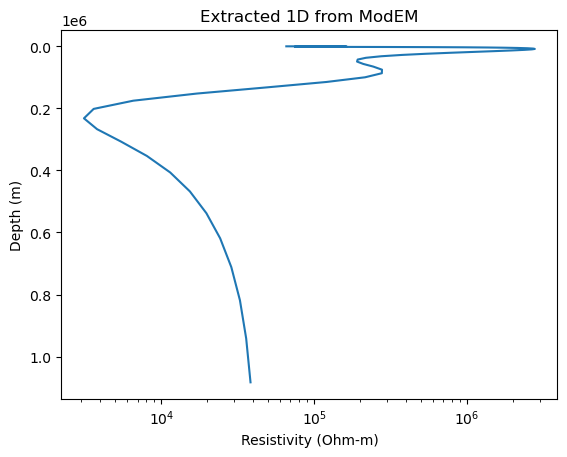

In [123]:
import matplotlib.pyplot as plt

plt.figure()
plt.semilogx(rho_1d, depth)

plt.gca().invert_yaxis()
plt.xlabel("Resistivity (Ohm-m)")
plt.ylabel("Depth (m)")
plt.title("Extracted 1D from ModEM")

plt.show()

In [124]:
rho_modem_log = np.log10(rho_1d)
depth_km = depth / 1000


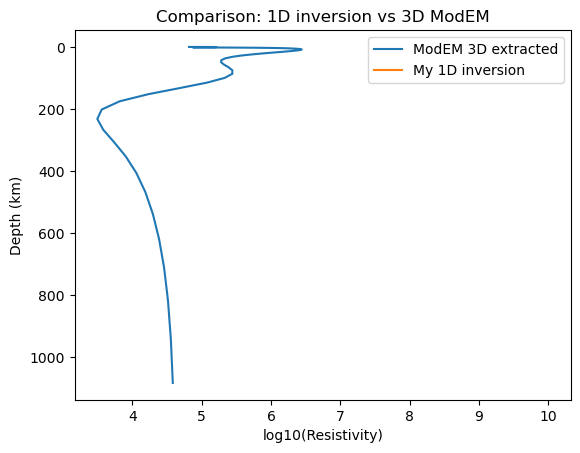

In [125]:
plt.figure()

# ModEM (converted)
plt.plot(rho_modem_log, depth_km, label="ModEM 3D extracted")

# Your inversion (middle panel curve)
plt.plot(10, 350, label="My 1D inversion")

plt.gca().invert_yaxis()
plt.xlabel("log10(Resistivity)")
plt.ylabel("Depth (km)")
plt.legend()

plt.title("Comparison: 1D inversion vs 3D ModEM")

plt.show()

In [126]:
%pip install h5py

Note: you may need to restart the kernel to use updated packages.


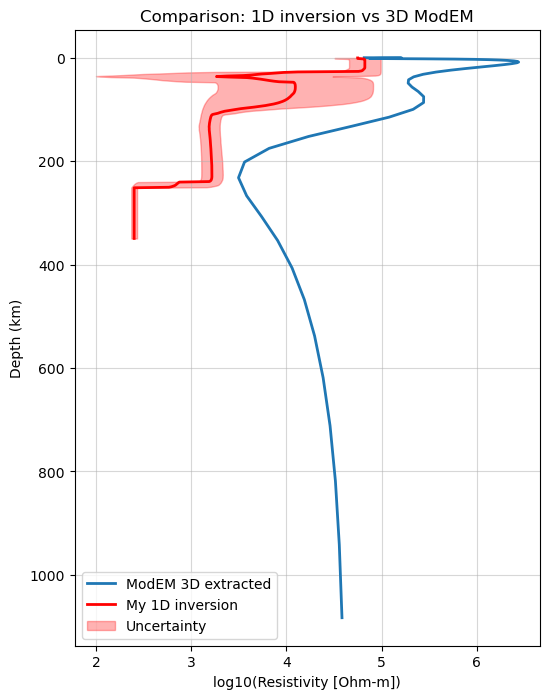

In [127]:

import h5py
import numpy as np
import matplotlib.pyplot as plt


mat_path = "../data_info_file/MT_TD_Chain_Stat_info_bot228.mat"

with h5py.File(mat_path, 'r') as f:
    S = f['S']
    
    rho_p5 = np.array(S['p5']).flatten()
    rho_p95 = np.array(S['p95']).flatten()

    # better estimate than mean
    rho_my_log = (rho_p5 + rho_p95) / 2
    depth_my_m = np.array(S['zPlot']).flatten()

depth_my_km = depth_my_m / 1000.0


plt.figure(figsize=(6, 8))

plt.plot(rho_modem_log, depth_km, label="ModEM 3D extracted", linewidth=2)

plt.plot(rho_my_log, depth_my_km, label="My 1D inversion", color='red', linewidth=2)

plt.fill_betweenx(
    depth_my_km,
    rho_p5,
    rho_p95,
    color='red',
    alpha=0.3,
    label='Uncertainty'
)

plt.gca().invert_yaxis()
plt.xlabel("log10(Resistivity [Ohm-m])")
plt.ylabel("Depth (km)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title("Comparison: 1D inversion vs 3D ModEM")

plt.show()

In [128]:

rho_inv_real = 10 ** rho_my_log

interp_func = interp1d(depth, rho_1d, bounds_error=False, fill_value=np.nan)
rho_modem_interp = interp_func(depth_my_m)

valid = (depth_my_m <= 300000)

valid = valid & (~np.isnan(rho_modem_interp))

# Misfit
misfit = np.log10(rho_inv_real[valid]) - np.log10(rho_modem_interp[valid])

rms = np.sqrt(np.mean(misfit**2))

print("RMS Misfit =", rms)

RMS Misfit = 1.2308718474399543


In [129]:
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv("output/csv/all_csv_files/selected_24_stations.csv")

# Loop over each station
for i, row in df.iterrows():
    lat = row["Lat"]
    lon = row["Lon"]
    site = row["Site"]

    # Distance calculation
    dist = np.sqrt((stations[:, 0] - lat)**2 + (stations[:, 1] - lon)**2)
    idx = np.argmin(dist)

    nearest_lat, nearest_lon = stations[idx]

    print(f"Station: {site}")
    print(f"Original: ({lat}, {lon})")
    print(f"Nearest : ({nearest_lat}, {nearest_lon})")
    print("-" * 50)

Station: SAMTEX.bot407.2005
Original: (-24.34572777777778, 25.52583055555555)
Nearest : (-24.345, 25.526)
--------------------------------------------------
Station: SAMTEX.mof107.2005
Original: (-20.456005555555556, 24.490555555555556)
Nearest : (-20.618, 24.416)
--------------------------------------------------
Station: SAMTEX.kim432.2004
Original: (-23.91631111111111, 18.546750000000003)
Nearest : (-24.056, 18.668)
--------------------------------------------------
Station: SAMTEX.san008.2008
Original: (-22.12839444444445, 24.176858333333335)
Nearest : (-22.128, 24.177)
--------------------------------------------------
Station: SAMTEX.san006.2008
Original: (-22.48900555555556, 24.169469444444445)
Nearest : (-22.489, 24.169)
--------------------------------------------------
Station: SAMTEX.bot228.2005
Original: (-24.13992222222222, 23.144805555555553)
Nearest : (-24.248, 23.294)
--------------------------------------------------
Station: SAMTEX.rtz401.2005
Original: (-24.236005555